# Statistisk proceskontrol af belægningstykkelse på tværs af produktionslinjer med PROC BOXPLOT

## Resumé

Denne notebook bruger **PROC BOXPLOT** til at udføre statistisk proceskontrol (SPC) på en kritisk-for-kvaliteten måling af belægningstykkelse indsamlet på tværs af fire parallelle produktionslinjer. Vi genererer syntetiske måledata inline, profilerer linjerne med `PROC MEANS` og tegner skeletale og skematiske boks-og-overskæg-plots, der sammenligner placering, spredning og haler på tværs af linjerne i ét diagram.

Vi vurderer derefter hver linje op mod den tekniske specifikation (mål 50.00 mm, grænser 49.80–50.20 mm) direkte fra statistikdatasættet **`OUTBOX=`** — de nøjagtige kvartiler, hegn og overskægsendepunkter bag hver boks — og demonstrerer til sidst **`OUTHISTORY=` / `HISTORY=`**-rundturen: PROC BOXPLOT eksporterer én kompakt opsummeringsrække pr. linje, og en anden PROC BOXPLOT rekonstruerer et identisk diagram direkte ud fra den opsummering, det mønster et dagligt SPC-dashboard bruger til at gentegne uden at genindlæse rå målinger.

På tværs af de fire linjer er **LINE-A bedst centreret** på målet (gennemsnit 50.008 mm), **LINE-C ligger lavt** (gennemsnit 49.932 mm, drivende mod LSL), og **LINE-D ligger både højt og mest variabelt** (gennemsnit 50.102 mm, std 0.080 mm) — dens maksimum på 50.248 mm er den eneste observation, der bryder den øvre specifikationsgrænse på 50.20 mm.

## Datakilder

Alle data er syntetiske og genereres inline af det første DATA-trin ved hjælp af `call streaminit(20250531)` og `rand()`. Der bruges ingen eksterne data eller netværksinput. Det faste frø gør hvert tal i denne notebook reproducerbart.

**Datasæt: `ProcessMeas`** (én række pr. målt emne)

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `Line` | Char(6) | Produktionslinjeidentifikator: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (gruppe-/klassifikationsvariablen) |
| `Shift` | Num | Produktionsskift-indeks 1–6 (indfører mild drift mellem skift) |
| `Thickness` | Num | Belægningstykkelse i mm (analysevariablen); mål 50.00 mm, specifikationsgrænser 49.80–50.20 mm |

Hver linje er centreret om et lidt forskelligt gennemsnit (50.00 / 50.04 / 49.92 / 50.10) med linjespecifik variation, der efterligner reelle forskelle fra udstyr til udstyr, og `LINE-B` indsprøjter lejlighedsvis et lille positivt udsving. DATA-trinnet løber over seks skift og fire linjer med undergruppestørrelser på cirka 18–25 emner hver; i dette ulicenserede miljø begrænser motoren outputtet til de første **100 observationer**, hvilket her lander som **38 / 19 / 21 / 22** emner for LINE-A til LINE-D — stadig rigeligt til at fylde fire veldefinerede bokse.

# Statistisk proceskontrol af belægningstykkelse med PROC BOXPLOT

I højvolumenproduktion er et boks-og-overskæg-plot arbejdshesten i SPC på produktionsgulvet: det opsummerer den centrale tendens, spredning og outliers for en kvalitetsegenskab for hver produktionsenhed i ét diagram. Her overvåger vi **belægningstykkelse (mm)** på et emne, der produceres parallelt på fire linjer (`LINE-A` til `LINE-D`). Den tekniske specifikation er et mål på **50.00 mm** med en nedre specifikationsgrænse (LSL) på **49.80 mm** og en øvre specifikationsgrænse (USL) på **50.20 mm**.

Vi vil:

1. Generere et syntetisk måledatasæt inline.
2. Profilere linjerne med `PROC MEANS`.
3. Tegne et grundlæggende skeletalt boksplot, derefter et skematisk plot, med specifikationsgrænserne overlejret som referencelinjer.
4. Opfange hver beregnet boksstatistik med `OUTBOX=` og vurdere hver linje op mod specifikationsgrænserne fra den tabel.
5. Gemme en kompakt undergruppeopsummering med `OUTHISTORY=` og bevise rundturen ved at gentegne direkte ud fra den med `HISTORY=`.

## Trin 1 — Generér syntetiske procesmålinger

DATA-trinnet nedenfor simulerer målinger over seks skift på fire linjer. Hver linje er bevidst centreret om et lidt forskelligt gennemsnit med sin egen variation, der efterligner reelle forskelle fra udstyr til udstyr, og en mild drift mellem skift lægges ovenpå med et `sin(Shift)`-led. Et fast frø (`streaminit(20250531)`) gør hver værdi i notebooken reproducerbar.

In [1]:
data ProcessMeas;
   CALL streaminit(20250531);
   LÆNGDE Line $6;
   TABEL lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   TABEL lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   TABEL LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   MÆRKAT Line='Produktionslinje' Thickness='Belægningstykkelse (mm)';
   GØR Shift = 1 TIL 6;
      GØR li = 1 TIL 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         GØR u = 1 TIL n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            HVIS li = 2 AND rand('uniform') < 0.05 SÅ
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            UDDATA;
         SLUT;
      SLUT;
   SLUT;
   FJERN li u n BASE;
KØR;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Trin 2 — Profilér linjerne

Før plottet bekræfter en hurtig `PROC MEANS`, at data landede som tilsigtet: fire linjer, beskedne men ikke-trivielle stikprøvestørrelser og gennemsnit samlet nær målet på 50.00 mm med linjespecifik spredning. Dette er den numeriske rygrad, boksplottet vil visualisere.

In [2]:
PROCEDURE GENNEMSNIT data=ProcessMeas n mean std MIN MAX maxdec=3;
   KLASSE Line;
   VARIABEL Thickness;
   TITEL 'Oversigt over belægningstykkelse pr. produktionslinje';
KØR;

                                 Oversigt over belægningstykkelse pr. produktionslinje                                  

                                                  The MEANS Procedure

                                 Analysis Variable : Thickness Belægningstykkelse (mm)

        Produktionslinje          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        LINE-A                       38         50.008          0.045         49.914         50.097
        LINE-B                       19         50.052          0.051         49.921         50.114
        LINE-C                       21         49.932          0.050         49.835         50.002
        LINE-D                       22         50.102          0.080         49.963         50.248
        -------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 3 — Grundlæggende skeletalt boksplot

Den enkleste kald kræver kun `PLOT analysis-var * group-var`-sætningen. Standardværdien `BOXSTYLE=SKELETAL` tegner overskæg til de mest ekstreme observationer inden for hver linje og giver en hurtig visuel sammenligning af placering og spredning på tværs af `LINE-A` til `LINE-D`.

                                   Skeletalt boksplot af belægningstykkelse pr. linje                                   

                                  Skeletalt boksplot af belægningstykkelse pr. linje

                                                 The BOXPLOT Procedure

Skeletal Plots for Belægningstykkelse (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10      


NOTE: Option TITLE changed to Skeletalt boksplot af belægningstykkelse pr. linje.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


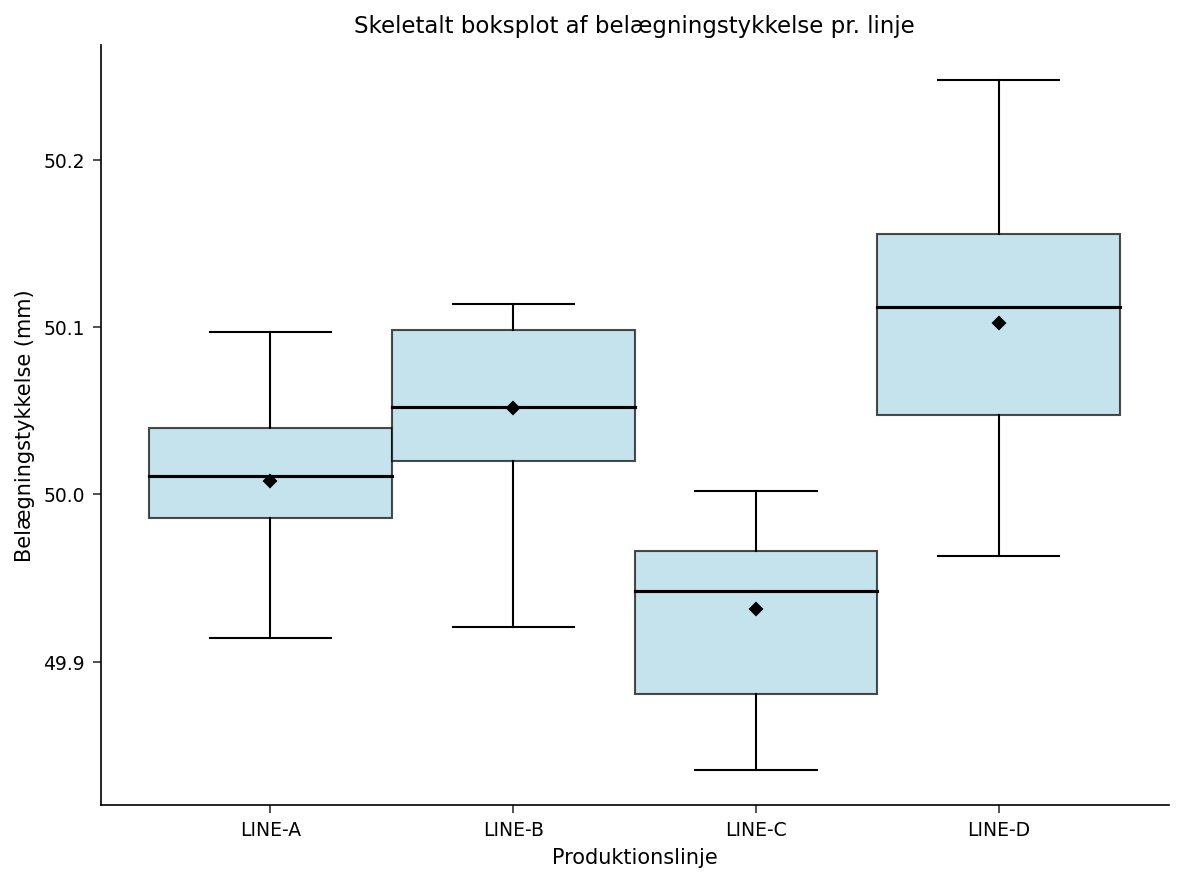

In [3]:
TITEL 'Skeletalt boksplot af belægningstykkelse pr. linje';
PROCEDURE boxplot data=ProcessMeas;
   PLOT Thickness*Line;
KØR;

## Trin 4 — Skematisk boksplot

Vi skifter til `BOXSTYLE=SCHEMATIC`. I skematisk stil afsluttes hvert overskæg ved den mest ekstreme observation, der stadig ligger inden for 1.5 × IQR-hegnene, og alle punkter uden for et hegn tegnes som en individuel outlier-markør. I denne stikprøve har ingen linje en indhegnet outlier — hver linjes spredning er kompakt nok til, at overskæggene når det sande minimum og maksimum — så det skematiske diagram ligner det skeletale, hvilket i sig selv er et nyttigt resultat: det fortæller ingeniøren, at ingen af de fire linjer kaster ekstreme emner. Bokskroppene gør stadig forskydningerne fra linje til linje åbenlyse på ét blik, og Trin 5 kvantificerer dem op mod specifikationsgrænserne.

                                 SPC skematisk boksplot af belægningstykkelse pr. linje                                 

                                SPC skematisk boksplot af belægningstykkelse pr. linje

                                                 The BOXPLOT Procedure

Schematic Plots for Belægningstykkelse (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10   


NOTE: Option TITLE changed to SPC skematisk boksplot af belægningstykkelse pr. linje.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


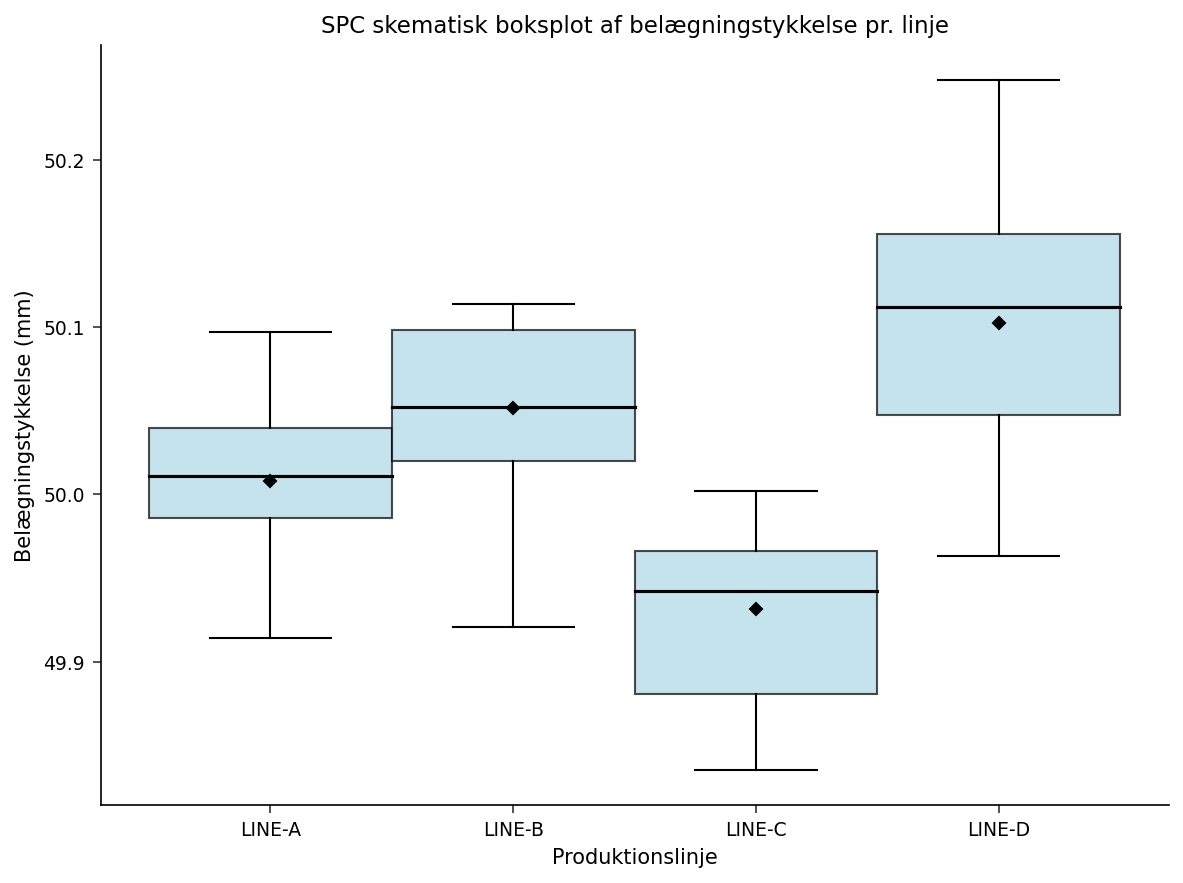

In [4]:
TITEL 'SPC skematisk boksplot af belægningstykkelse pr. linje';
PROCEDURE boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
KØR;

## Trin 5 — Eksportér boksstatistik og vurdér op mod specifikationsgrænserne

Optionen `OUTBOX=` opfanger hver beregnet boksstatistik til et datasæt — for hver linje: det lave overskæg (`L`), Q1 (`1`), gennemsnit (`X`), median (`M`), Q3 (`3`), det høje overskæg (`H`), standardafvigelse (`S`) og N. Dette er den numeriske protokol, en revisor har brug for bag billedet, og det er også den reneste måde at kontrollere hver linje op mod specifikationen 49.80 / 50.20 mm. Vi slår `GRID` til for lettere aflæsning, eksporterer `BoxStats`, udskriver det og kører derefter et kort DATA-trin, der markerer enhver linje, hvis overskægsspændvidde skubber ud over en specifikationsgrænse.

                                   Skematisk boksplot med gitter og statistikeksport                                    

                                   Skematisk boksplot med gitter og statistikeksport

                                                 The BOXPLOT Procedure

Schematic Plots for Belægningstykkelse (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10     


NOTE: Option TITLE changed to Skematisk boksplot med gitter og statistikeksport.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Beregnet boksstatistik (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Specifikationsgrænse-vurdering pr. linje.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


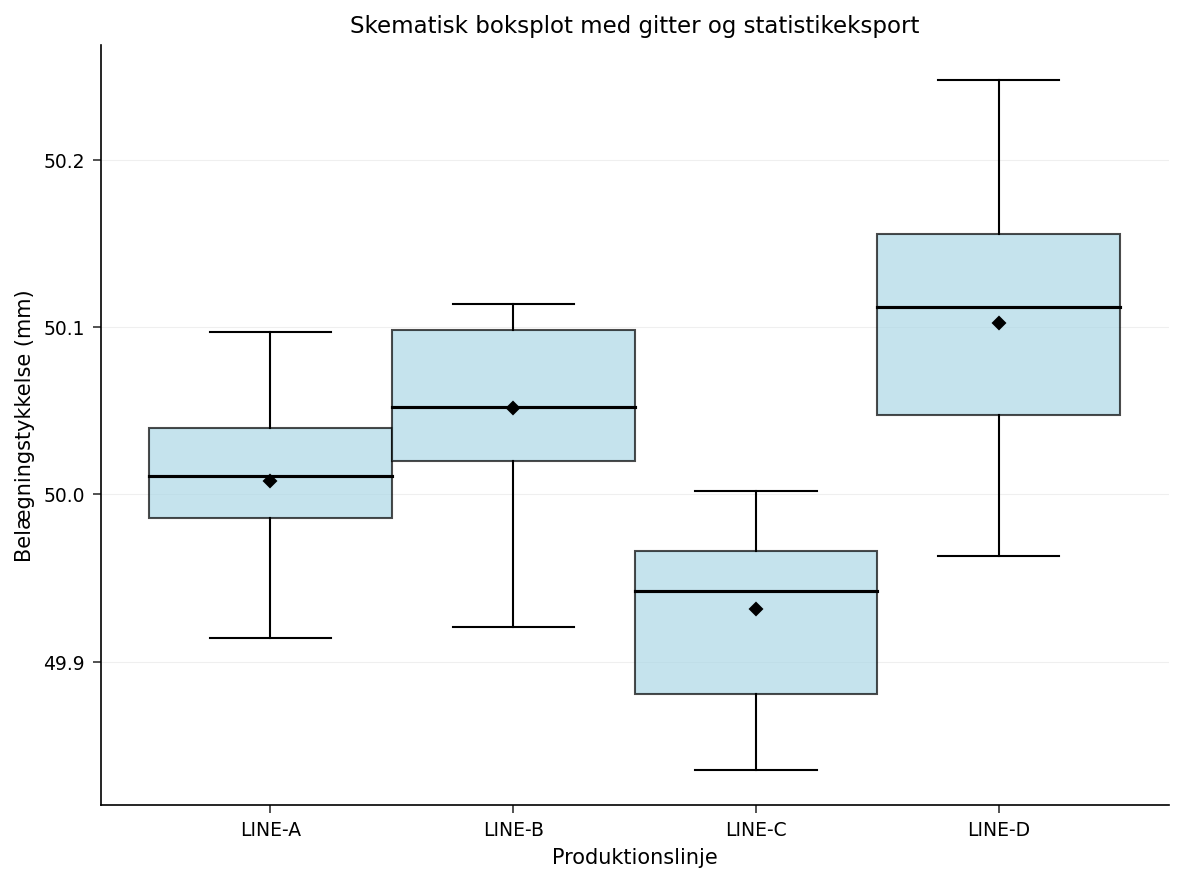

In [5]:
TITEL 'Skematisk boksplot med gitter og statistikeksport';
PROCEDURE boxplot data=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
KØR;

TITEL 'Beregnet boksstatistik (OUTBOX=)';
PROCEDURE UDSKRIV data=BoxStats noobs;
KØR;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
data SpecCheck;
   SÆT BoxStats;
   LÆNGDE Status $40;
   LSL = 49.80;
   USL = 50.20;
   HVIS THICKNESSH > USL SÅ Status = 'Høje emner overskrider USL';
   ELLERS HVIS THICKNESSL < LSL SÅ Status = 'Lave emner under LSL';
   ELLERS Status = 'Inden for specifikation';
   BEHOLD LINE THICKNESSL THICKNESSH LSL USL Status;
KØR;

TITEL 'Specifikationsgrænse-vurdering pr. linje';
PROCEDURE UDSKRIV data=SpecCheck noobs label;
   MÆRKAT LINE='Linje' THICKNESSL='Lavt overskæg' THICKNESSH='Højt overskæg' LSL='LSL' USL='USL' Status='Status';
KØR;

## Trin 6 — Bevar en overvågningshistorik og gentegn ud fra den

I løbende SPC genindlæser man sjældent hver rå måling. `OUTHISTORY=` skriver én opsummeringsrække pr. linje (samme layout, som `HISTORY=` forbruger), så de tunge rådata kan arkiveres. Nedenfor eksporterer vi `LineHistory`, udskriver det og beviser derefter rundturen ved at føre det direkte tilbage ind i en ny `PROC BOXPLOT` via `HISTORY=` — præcis som et dagligt dashboard ville genbruge foraggregerede undergruppestatistikker.

                                             Eksport af undergruppehistorik                                             

                                             Eksport af undergruppehistorik

                                                 The BOXPLOT Procedure

Skeletal Plots for Belægningstykkelse (mm)

Produktionslinje      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-


NOTE: Option TITLE changed to Eksport af undergruppehistorik.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Opsummeringshistorik-datasæt (én række pr. linje).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Boksplot rekonstrueret fra opsummeringshistorik.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


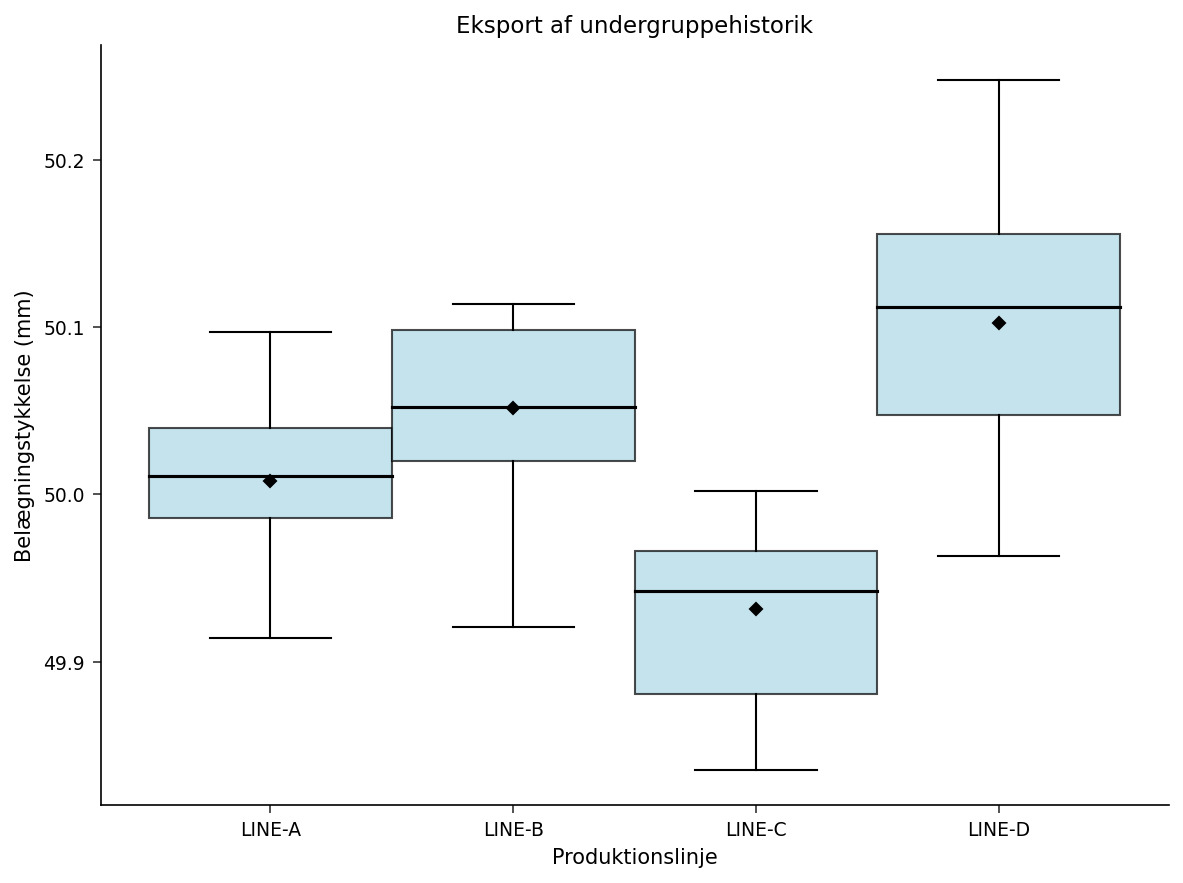

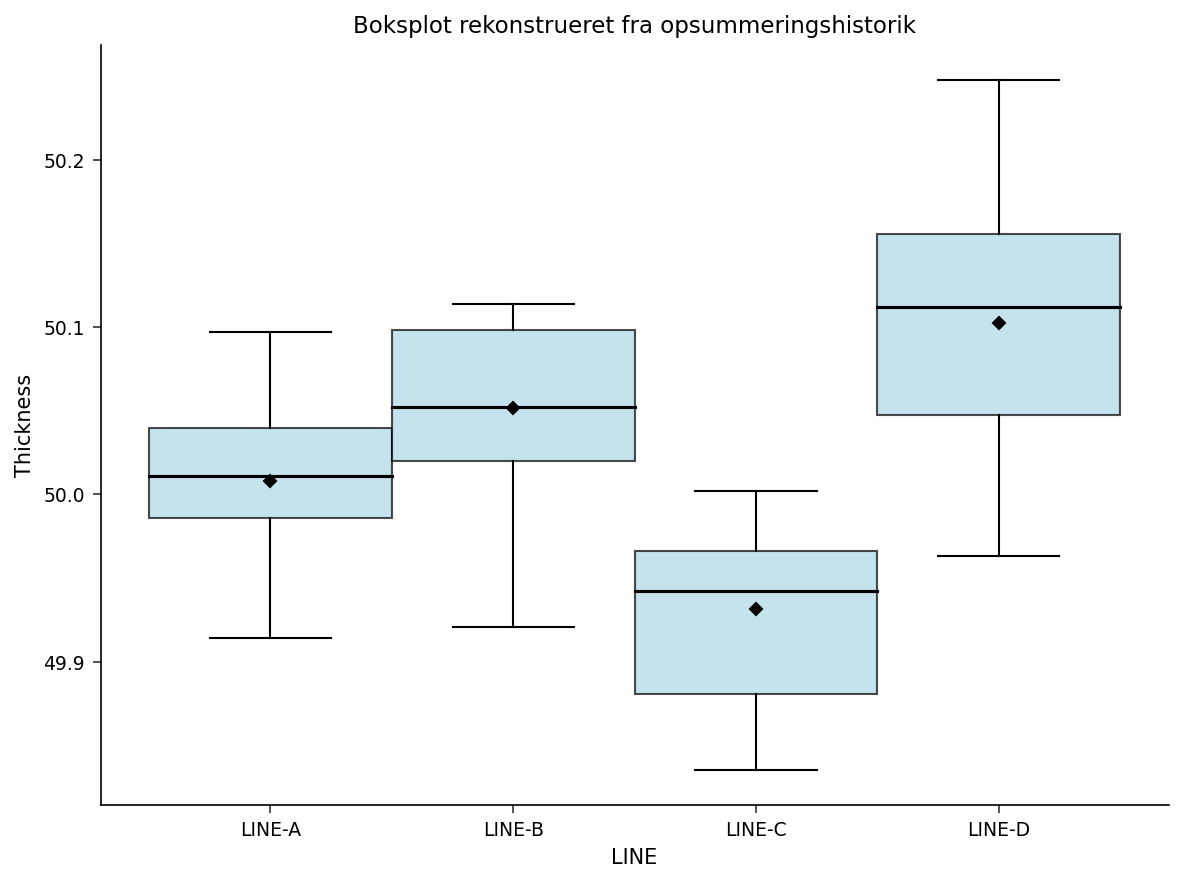

In [6]:
TITEL 'Eksport af undergruppehistorik';
PROCEDURE boxplot data=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
KØR;

TITEL 'Opsummeringshistorik-datasæt (én række pr. linje)';
PROCEDURE UDSKRIV data=LineHistory noobs;
KØR;

TITEL 'Boksplot rekonstrueret fra opsummeringshistorik';
PROCEDURE boxplot history=LineHistory;
   PLOT Thickness*Line;
KØR;

## Fortolkning af resultaterne

Ved at læse boksplottene sammen med `PROC MEANS`-profilen, `OUTBOX=`-tabellen og specifikationsgrænse-vurderingen:

- **Centrering.** `LINE-A` er bedst centreret om målet på 50.00 mm (gennemsnit 50.008 mm, median 50.011 mm). `LINE-B` ligger let højt (gennemsnit 50.052 mm). `LINE-C` ligger lavt (gennemsnit 49.932 mm, median 49.942 mm), linjen driver mod LSL. `LINE-D` ligger højt (gennemsnit 50.102 mm, median 50.112 mm), linjen tættest på USL.
- **Spredning.** `LINE-D` viser den bredeste boks og de længste overskæg — dens standardafvigelse på 0.080 mm er cirka 60–80 % større end de øvrige tre linjer (0.045–0.051 mm), hvilket markerer den som den mindst stabile linje og den bedste kandidat til en variationsreduktionsundersøgelse. `LINE-A` er den strammeste (std 0.045 mm).
- **Haler.** I skematisk stil producerer ingen linje en indhegnet outlier: hvert overskæg når sin linjes sande minimum/maksimum, så processen kaster ikke isolerede ekstreme emner. Spredningsforskellene drives af hovedparten af hver fordeling, ikke af enkeltstående punkter.
- **Specifikationsoverholdelse.** `OUTBOX=`-overskægsendepunkterne, vurderet op mod 49.80 / 50.20 mm, placerer `LINE-A`, `LINE-B` og `LINE-C` fuldt **inden for specifikationen**. `LINE-D` er undtagelsen: dens høje overskæg når **50.248 mm**, forbi **USL på 50.20 mm** — høje emner på `LINE-D` overskrider den øvre specifikation.
- **Operationalisering.** `OUTBOX=`-datasættet giver revisorer de nøjagtige kvartiler, overskægsendepunkter, gennemsnit og standardafvigelse bag billedet, og `OUTHISTORY=` leverer en kompakt, gentegnbar opsummering med én række pr. linje (Trin 6), så diagrammet kan regenereres efter en tidsplan uden at bevare de rå målinger — boksplottet rekonstrueret fra opsummeringen er identisk med det, der er tegnet ud fra rådata.

**Handlingspunkter:** prioritér `LINE-D` — gencentrér den både nedad mod målet og igangsæt en variationsreduktionsundersøgelse for at trække dens høje overskæg tilbage inden for USL; skub `LINE-C` op mod målet, før dens lave hale når LSL; `LINE-A` og `LINE-B` kører acceptabelt.